<a href="https://colab.research.google.com/github/dilp90/InteligenciaArtificial_y_RedesNeuronales_UANL_FIME/blob/main/MachineLearning/AprendizajeNoSupervisado/1_K_means_NoSupervisado.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Aprendizaje no supervisado: K-means**

El modelo K-Means es un algoritmo de aprendizaje no supervisado utilizado para agrupar datos en subconjuntos llamados clusters. Ayuda a descubrir patrones ocultos sin necesidad de etiquetas previas.

¿Cómo funciona k-means?

* Eliges un número de clusters (k) que quieres encontrar

* Se inicializan aleatoriamente k puntos llamados centroides (uno por cluster).

* Cada punto de datos se asigna al centroide más cercano (esto forma los clusters).

* Se recalculan los centroides como el promedio de todos los puntos en cada cluster.

* Se repiten los pasos 3 y 4 hasta que los centroides ya no cambien mucho (converge).

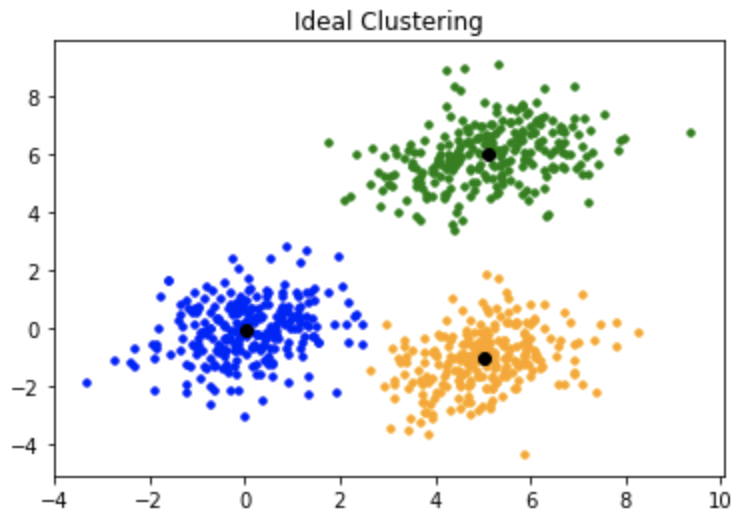

## **Ejemplo con k-means**

En una celda robótica, diferentes actuadores (motores, servos, solenoides) son monitoreados durante su operación. Se registran datos de consumo eléctrico en diferentes momentos de trabajo. No se sabe de antemano cuántos "modos" de operación hay, pero se quiere descubrir agrupamientos naturales en esos datos.



In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

Datos simulados:
* Entrada: cada fila representa una medición con estas características:

  * Consumo de corriente promedio (A)

  * Duración del ciclo (s)

In [2]:
# Simulación de datos para 3 patrones distintos
grupo1 = np.random.normal(loc=[2, 1], scale=0.2, size=(50, 2))  # Motores pequeños
grupo2 = np.random.normal(loc=[5, 3], scale=0.3, size=(50, 2))  # Servomotores
grupo3 = np.random.normal(loc=[8, 2], scale=0.3, size=(50, 2))  # Solenoides

X = np.vstack((grupo1, grupo2, grupo3))

In [6]:
# Aplicar K-Means con 3 clusters
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans.fit(X)
labels = kmeans.labels_

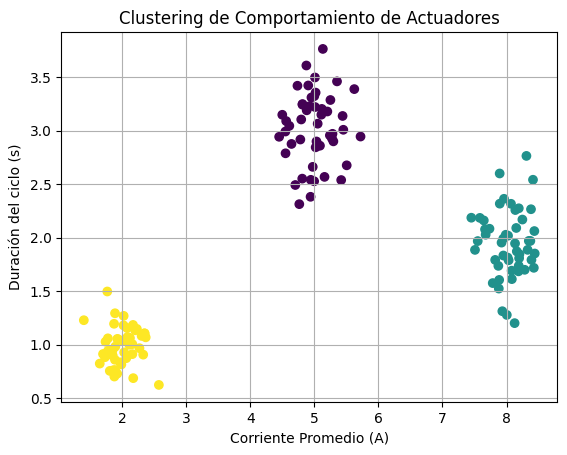

In [7]:
# Visualización
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis')
plt.xlabel('Corriente Promedio (A)')
plt.ylabel('Duración del ciclo (s)')
plt.title('Clustering de Comportamiento de Actuadores')
plt.grid(True)
plt.show()

## **Implementar método del codo en K-means**

¿En qué consiste?

* Se entrena el modelo K-Means varias veces, usando diferentes valores de k (número de clusters), por ejemplo, desde k=1 hasta k=10.

* Para cada k, se calcula una medida llamada inercia (también conocida como suma de errores cuadráticos intra-cluster), que indica qué tan compactos están los puntos dentro de cada cluster.

* Se grafica el número de clusters (k) en el eje X y la inercia en el eje Y.

* El gráfico resultante suele mostrar una curva decreciente, porque mientras más clusters se usen, más cerca estarán los puntos de su centroide.

* El “codo” de la curva (el punto donde la disminución de la inercia se vuelve menos pronunciada) indica el mejor balance entre simplicidad y precisión.

In [8]:
# Simulación de datos (igual que antes)
grupo1 = np.random.normal(loc=[2, 1], scale=0.2, size=(50, 2))
grupo2 = np.random.normal(loc=[5, 3], scale=0.3, size=(50, 2))
grupo3 = np.random.normal(loc=[8, 2], scale=0.3, size=(50, 2))
X = np.vstack((grupo1, grupo2, grupo3))

In [9]:
# Método del codo
inertias = []
k_range = range(1, 10)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X)
    inertias.append(kmeans.inertia_)

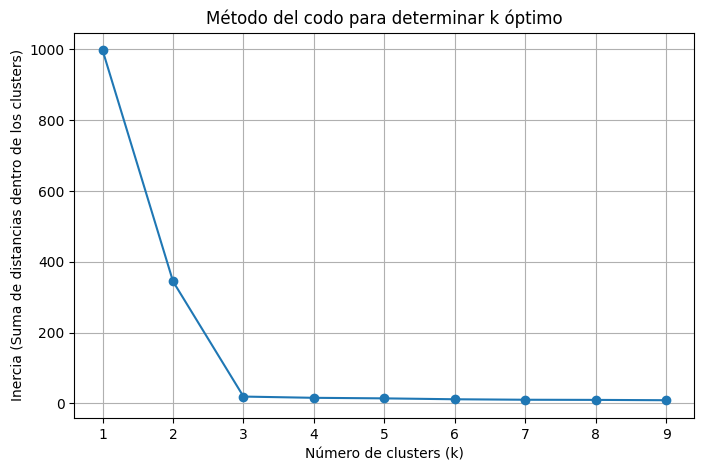

In [10]:
# Graficar la curva del codo
plt.figure(figsize=(8, 5))
plt.plot(k_range, inertias, marker='o')
plt.xlabel('Número de clusters (k)')
plt.ylabel('Inercia (Suma de distancias dentro de los clusters)')
plt.title('Método del codo para determinar k óptimo')
plt.grid(True)
plt.show()